In [4]:
import numpy as np
import cvxpy as cp

# Dimensions
n, p = 15, 8

# Matrices données
X = np.array([
    [1,0,0,0,0,0,0,0],
    [0,1,0,0,0,0,0,0],
    [0,0,1,0,0,0,0,0],
    [0,0,0,1,0,0,0,0],
    [0,0,0,0,1,0,0,0],
    [0,0,0,0,0,1,0,0],
    [0,0,0,0,0,0,1,0],
    [0,0,0,0,0,0,0,1],
    [1,1,0,0,0,0,0,0],
    [0,0,1,1,0,0,0,0],
    [0,0,0,0,1,1,0,0],
    [0,0,0,0,0,0,1,1],
    [1,0,1,0,0,0,0,0],
    [0,1,0,1,0,0,0,0],
    [1,1,1,1,0,0,0,0]
])

R = np.array([
    [1,0,1,0,-1,0,-1,0],
    [0,1,0,1,0,-1,0,-1],
    [1,1,1,1,-1,-1,-1,-1]
])

# Données fictives
Y = np.array([20, 12, 23, 10, 7, 9, 13, 21, 23, 24, 25, 20, 20, 27, 59])
sigma2 = np.linspace(10, 30, 15)  # variances hétéroscédastiques
Omega = np.diag(sigma2)
Omega_inv = np.diag(1 / sigma2)

# Variables
beta = cp.Variable(p)

# Objectif : moindres carrés pondérés
objective = cp.Minimize(cp.quad_form(Y - X @ beta, Omega_inv))

# Contraintes
constraints = [
    R @ beta == 0,
    beta >= 0
]

# Problème
problem = cp.Problem(objective, constraints)
problem.solve()

X_beta = X @ beta.value
X_beta_rounded = np.round(X_beta).astype(int)
print("X*beta estimé :", X_beta_rounded)

X*beta estimé : [13 13 15 12 14 10 14 15 26 27 24 29 28 25 53]


Beta estimé: [ 1.43174964e-01 -6.17278771e-22  3.94822843e-01  3.59713057e-01
 -1.95251720e-21 -1.41554911e-21  5.37997807e-01  3.59713057e-01]


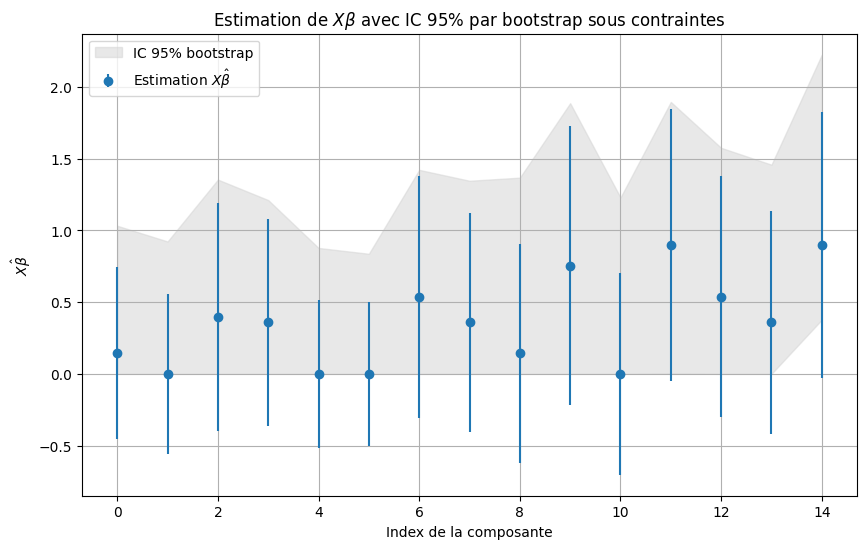

In [15]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

# Données d'exemple (à remplacer par tes données)
n, p = 15, 8
X = np.array([
    [1, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 1],
    [1, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 1],
    [1, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 0, 1, 0, 0, 0, 0],
    [1, 1, 1, 1, 0, 0, 0, 0]
])
Omega_diag = np.ones(n)  # Exemple : variance unitaire, adapte si besoin
Omega_sqrt = np.sqrt(Omega_diag)

R = np.array([
    [1, 0, 1, 0, -1, 0, -1, 0],
    [0, 1, 0, 1, 0, -1, 0, -1],
    [1, 1, 1, 1, -1, -1, -1, -1]
])

# Vecteur Y observé (exemple aléatoire)
np.random.seed(42)
beta_true = np.array([0.3, 0.4, 0.1, 0.5, 0.4, 0.0, 0.0, 0.8])
epsilon = np.random.normal(0, 1, n)
Y = X @ beta_true + epsilon

# --- Estimation initiale ---

beta = cp.Variable(p)
objective = cp.Minimize(cp.sum_squares(cp.multiply(1 / Omega_sqrt, X @ beta - Y)))
constraints = [R @ beta == 0, beta >= 0]
problem = cp.Problem(objective, constraints)
problem.solve(solver=cp.OSQP)

beta_hat = beta.value
X_beta_hat = X @ beta_hat

print("Beta estimé:", beta_hat)

# --- Bootstrap pour variance ---

B = 500  # nombre de simulations bootstrap
X_beta_bootstrap = np.zeros((n, B))

for b in range(B):
    epsilon_b = np.random.normal(0, Omega_sqrt)  # bruit selon Omega
    Y_b = X_beta_hat + epsilon_b

    beta_b = cp.Variable(p)
    obj_b = cp.Minimize(cp.sum_squares(cp.multiply(1 / Omega_sqrt, X @ beta_b - Y_b)))
    cons_b = [R @ beta_b == 0, beta_b >= 0]
    prob_b = cp.Problem(obj_b, cons_b)
    prob_b.solve(solver=cp.OSQP)

    if beta_b.value is not None:
        X_beta_bootstrap[:, b] = X @ beta_b.value
    else:
        X_beta_bootstrap[:, b] = np.nan  # si problème

# Variance empirique
X_beta_var = np.nanvar(X_beta_bootstrap, axis=1)
X_beta_std = np.sqrt(X_beta_var)

# Intervalle de confiance à 95%
ci_lower = np.nanpercentile(X_beta_bootstrap, 2.5, axis=1)
ci_upper = np.nanpercentile(X_beta_bootstrap, 97.5, axis=1)

# --- Affichage graphique ---

plt.figure(figsize=(10, 6))
plt.errorbar(range(n), X_beta_hat, yerr=1.96 * X_beta_std, fmt='o', label='Estimation $X\\hat{\\beta}$')
plt.fill_between(range(n), ci_lower, ci_upper, color='lightgray', alpha=0.5, label='IC 95% bootstrap')
plt.xlabel('Index de la composante')
plt.ylabel('$X\\hat{\\beta}$')
plt.title('Estimation de $X\\beta$ avec IC 95% par bootstrap sous contraintes')
plt.legend()
plt.grid(True)
plt.show()


In [6]:
import numpy as np
import cvxpy as cp

# Dimensions
n, p = 18, 10

# Matrices données
X = np.array([
    [1,0,0,0,0,0,0,0,0,0],
    [0,1,0,0,0,0,0,0,0,0],
    [0,0,1,0,0,0,0,0,0,0],
    [0,0,0,1,0,0,0,0,0,0],
    [0,0,0,0,1,0,0,0,0,0],
    [0,0,0,0,0,1,0,0,0,0],
    [0,0,0,0,0,0,1,0,0,0],
    [0,0,0,0,0,0,0,1,0,0],
    [0,0,0,0,0,0,0,0,1,0],
    [0,0,0,0,0,0,0,0,0,1],
    [1,0,1,0,1,0,0,0,0,0],
    [0,1,0,1,0,1,0,0,0,0],
    [1,1,0,0,0,0,0,0,0,0],
    [0,0,1,1,0,0,0,0,0,0],
    [0,0,0,0,1,1,0,0,0,0],
    [1,1,1,1,1,1,0,0,0,0],
    [0,0,0,0,0,0,1,1,0,0],
    [0,0,0,0,0,0,0,0,1,1],
])

R = np.array([
    [1,0,1,0,1,0,-1,0,-1,0],
    [1,1,1,1,1,-1,-1,-1,-1,-1]
])


# Données fictives
Y = np.array([12, 11, 14, 9, 17, 2, 7, 9, 13, 21, 20, 27, 15, 17, 15, 59, 25, 20])
sigma2 = np.array([25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25])  # variances hétéroscédastiques
Omega = np.diag(sigma2)
Omega_inv = np.diag(1 / sigma2)

# Variables
beta = cp.Variable(p)

# Objectif : moindres carrés pondérés
objective = cp.Minimize(cp.quad_form(Y - X @ beta, Omega_inv))

# Contraintes
constraints = [
    R @ beta == 0,
    beta >= 0
]


# Problème
problem = cp.Problem(objective, constraints)
problem.solve()

X_beta = X @ beta.value
X_beta_rounded = np.round(X_beta).astype(int)
print("X*beta estimé :", X_beta_rounded)

# Matrice de variance-covariance de beta_hat
Xt_Omega_inv = X.T @ Omega_inv
V_beta = np.linalg.inv(Xt_Omega_inv @ X)

# Matrice de variance de X @ beta
V_Xbeta = X @ V_beta @ X.T

# Extraire uniquement les variances (diagonale)
var_Xbeta = np.diag(V_Xbeta)

print("Variances de Xβ :", var_Xbeta)


X*beta estimé : [ 5 14  8 12 13  3 13  9 12 14 25 29 18 20 16 54 23 25]
Variances de Xβ : [12.5        12.5        12.5        12.5        12.5        12.5
 16.66666667 16.66666667 16.66666667 16.66666667 12.5        12.5
 12.5        12.5        12.5        12.5        16.66666667 16.66666667]


In [2]:
import numpy as np
from scipy.optimize import minimize

def compute_H(X, W):
    return X.T @ W @ X

def compute_P(H, R):
    H_inv = np.linalg.inv(H)
    RHinv = R @ H_inv
    middle = np.linalg.inv(RHinv @ R.T)
    return H_inv - H_inv @ R.T @ middle @ RHinv

def var_Xbeta_diag_constrained(w, X, R, target_var):
    W = np.diag(w)
    H = compute_H(X, W)
    P = compute_P(H, R)
    V = X @ P @ X.T
    return np.sum((np.diag(V) - target_var)**2)

# Exemple
X = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1],
    [1, 0, 1, 0],
    [0, 1, 0, 1],
    [1, 1, 0, 0],
    [0, 0, 1, 1],
    [1, 1, 1, 1],
])

R = np.array([[1, 0, -1, 0]])  # exemple de contrainte : β₁ = β₃
target_var = np.ones(X.shape[0])  # par exemple : on veut que chaque composante ait variance 1

res = minimize(
    var_Xbeta_diag_constrained,
    x0=np.ones(X.shape[0]),  # initialisation
    args=(X, R, target_var),
    bounds=[(1e-6, None)] * X.shape[0]  # w_i > 0
)

w_opt = res.x
omega_opt = np.diag(1 / w_opt)
print(omega_opt)

[[ 1.41121191  0.          0.          0.          0.          0.
   0.          0.          0.        ]
 [ 0.          3.00000002  0.          0.          0.          0.
   0.          0.          0.        ]
 [ 0.          0.          1.41121195  0.          0.          0.
   0.          0.          0.        ]
 [ 0.          0.          0.          2.99999977  0.          0.
   0.          0.          0.        ]
 [ 0.          0.          0.          0.         48.32169386  0.
   0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.          1.71428611
   0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   3.00000001  0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          3.00000002  0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.          1.7142861 ]]


In [4]:
import cvxpy as cp
import numpy as np

# ---- INPUTS ----
n, p, q = 9, 4, 1  # Dimensions
rho = 100          # Total budget (sum of variances)
p_weights = np.ones(n)  # Poids
C_target = 5

# Matrices X et R
X = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1],
    [1, 0, 1, 0],
    [0, 1, 0, 1],
    [1, 1, 0, 0],
    [0, 0, 1, 1],
    [1, 1, 1, 1],
])
R = np.array([[1, 0, -1, 0]])

# ---- VARIABLES ----
sigma2 = cp.Variable(n, pos=True)
Omega_inv = cp.diag(1 / sigma2)

# ---- INTERMÉDIAIRES ----
H = X.T @ Omega_inv @ X

# Résolution de systèmes au lieu d'inverses
I_p = np.eye(p)

# H^{-1} @ R^T
Z = cp.solve(H, R.T)  # p x q
# (R H^{-1} R^T)^{-1}
M = cp.inv_pos(R @ Z)  # q x q
# P = H^{-1} - H^{-1} R^T (R H^{-1} R^T)^{-1} R H^{-1}
P = cp.solve(H, I_p) - Z @ M @ Z.T  # p x p

# diag(X P X^T)
XPX_T = X @ P @ X.T
diag_XPX_T = cp.diag(XPX_T)

# ---- OBJECTIF ----
target_diag = C_target * p_weights
objective = cp.Minimize(cp.sum_squares(diag_XPX_T - target_diag))

# ---- CONTRAINTES ----
constraints = [cp.sum(sigma2) == rho]

# ---- RÉSOLUTION ----
prob = cp.Problem(objective, constraints)
prob.solve()

# ---- AFFICHAGE ----
print("⭐️ Variances optimales (σ²) :", sigma2.value)
print("📏 Somme totale :", np.sum(sigma2.value))
print("🎯 Diagonale visée :", target_diag)
print("📐 Diagonale obtenue :", diag_XPX_T.value)


AttributeError: module 'cvxpy' has no attribute 'solve'

# Tentative d'application

## Fonction

In [313]:
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations
from collections import defaultdict

def plot_subset_graph_with_counts(liste_request):
    # Toutes les variables utilisées
    toutes_variables = set().union(*liste_request)
    dict_nb_modalite_variables = {var: 2 for var in toutes_variables}

    # Tous les sous-ensembles possibles
    def powerset_frozensets(iterable):
        return [frozenset(s) for r in range(len(iterable)+1) for s in combinations(iterable, r)]
    
    all_vars = list(dict_nb_modalite_variables.keys())
    all_nodes = powerset_frozensets(all_vars)

    # Graphe complet (flèches descendantes)
    full_graphe = {fs: [] for fs in all_nodes}
    for parent in all_nodes:
        for enfant in all_nodes:
            if len(enfant) == len(parent) + 1 and parent.issubset(enfant):
                full_graphe[parent].append(enfant)

    # Construction du graphe orienté (flèches vers les parents)
    G = nx.DiGraph()
    for parent, enfants in full_graphe.items():
        for enfant in enfants:
            G.add_edge(enfant, parent)

    # Nœuds demandés
    noeuds_request = set(liste_request)
    feuilles = [
        n for n in noeuds_request
        if all(child not in noeuds_request for child in G.predecessors(n))
    ]

    # Calcul des niveaux
    def compute_levels(graphe):
        return {node: len(node) for node in graphe}

    levels = compute_levels(G)
    niveau_max_feuilles = max(levels[n] for n in feuilles) - 1

    # Élagage des nœuds gris inutiles
    noeuds_manquants = set(G.nodes) - noeuds_request
    noeuds_gris_trop_profond = [n for n in noeuds_manquants if levels[n] > niveau_max_feuilles]
    G.remove_nodes_from(noeuds_gris_trop_profond)

    noeuds_gris_restants = set(G.nodes) - noeuds_request
    noeuds_gris_sans_parents = [n for n in noeuds_gris_restants if G.in_degree(n) == 0]
    G.remove_nodes_from(noeuds_gris_sans_parents)

    # Recalcul des feuilles (après élagage)
    feuilles = [
        n for n in noeuds_request
        if n in G.nodes and all(child not in noeuds_request for child in G.predecessors(n))
    ]

    # Couleurs et tailles
    noeuds_orange = feuilles
    node_colors = [
        "orange" if n in noeuds_orange else
        "lightgreen" if n in noeuds_request else
        "lightgray"
        for n in G.nodes
    ]
    node_sizes = [
        1200 if n in noeuds_orange else
        800 if n in noeuds_request else
        500
        for n in G.nodes
    ]

    # Layout manuel
    def manual_tree_layout(graphe):
        levels = compute_levels(graphe)
        pos = {}
        nodes_by_level = {}
        for node, lvl in levels.items():
            nodes_by_level.setdefault(lvl, []).append(node)
        for lvl, nodes in nodes_by_level.items():
            for i, node in enumerate(sorted(nodes, key=lambda x: sorted(x))):
                pos[node] = (i, -lvl)
        return pos

    pos = manual_tree_layout(G)

    # Labels lisibles
    labels = {n: ','.join(sorted(n)) if n else '∅' for n in G.nodes}

    # --- Affichage
    plt.figure(figsize=(14, 10))
    nx.draw(
        G,
        pos,
        labels=labels,
        node_size=node_sizes,
        node_color=node_colors,
        edgecolors="black",
        linewidths=1.5,
        arrows=True,
        font_size=10
    )

    # --- Propagation orange vers le haut
    count_orange_reaching = {node: 0 for node in G.nodes}
    for orange in noeuds_orange:
        visited = set()
        stack = [orange]
        while stack:
            current = stack.pop()
            for parent in G.successors(current):
                if parent not in visited:
                    count_orange_reaching[parent] += 1
                    visited.add(parent)
                    stack.append(parent)

    levels = compute_levels(G)
    max_level = max(levels.values())

    threshold = 1
    for lvl in range(max_level, -1, -1):
        nodes_at_level = [n for n, l in levels.items() if l == lvl]
        nodes_above = [n for n in nodes_at_level if count_orange_reaching.get(n, 0) > threshold]
        threshold = max(len(nodes_above), 1)
        for node in nodes_above:
            if node in noeuds_orange:
                continue
            x, y = pos[node]
            plt.text(
                x + 0.15, y,
                str(1),
                fontsize=15,
                ha='center',
                va='bottom',
                color='black'
            )

    plt.title("Arbre des sous-ensembles — Feuilles en orange, seuils propagés", fontsize=14)
    plt.axis("off")
    plt.show()


def plot_subset_tree(liste_request):
    dict_nb_modalite_variables = {}
    for fs in liste_request:
        for var in fs:
            dict_nb_modalite_variables[var] = 2  # hypothèse : 2 modalités par défaut

    def powerset_frozensets(iterable):
        return [frozenset(s) for r in range(len(iterable)+1) for s in combinations(iterable, r)]

    all_vars = list(dict_nb_modalite_variables.keys())
    all_nodes = powerset_frozensets(all_vars)

    full_graphe = {fs: [] for fs in all_nodes}
    for parent in all_nodes:
        for enfant in all_nodes:
            if len(enfant) == len(parent) + 1 and parent.issubset(enfant):
                full_graphe[parent].append(enfant)

    def compute_levels(graphe_nodes):
        return {node: len(node) for node in graphe_nodes}

    def manual_tree_layout(graphe):
        levels = compute_levels(graphe.nodes)
        pos = {}
        nodes_by_level = {}
        for node, lvl in levels.items():
            nodes_by_level.setdefault(lvl, []).append(node)
        for lvl, nodes in nodes_by_level.items():
            for i, node in enumerate(sorted(nodes, key=lambda x: sorted(x))):
                pos[node] = (i, -lvl)
        return pos

    G = nx.DiGraph()
    for parent, enfants in full_graphe.items():
        for enfant in enfants:
            G.add_edge(enfant, parent)

    noeuds_request = set(liste_request)
    feuilles = [
        n for n in noeuds_request
        if all(child not in noeuds_request for child in G.predecessors(n))
    ]

    # Couleurs initiales
    node_colors = []
    for n in G.nodes:
        if n in feuilles:
            node_colors.append("orange")
        elif n in noeuds_request:
            node_colors.append("lightgreen")
        else:
            node_colors.append("lightgray")

    # Calculer les niveaux de tous les nœuds
    levels = compute_levels(G.nodes)

    niveau_max_feuilles = max(levels[n] for n in feuilles) - 1

    nodes_to_remove_gris = [n for n in G.nodes if n not in noeuds_request and levels[n] > niveau_max_feuilles]
    G.remove_nodes_from(nodes_to_remove_gris)

    nodes_to_remove = [n for n in G.nodes if n not in noeuds_request and G.in_degree(n) == 0]
    G.remove_nodes_from(nodes_to_remove)

    # Recalculer feuilles et couleurs après suppression
    noeuds_request = set(n for n in noeuds_request if n in G.nodes)
    feuilles = [
        n for n in noeuds_request
        if all(child not in noeuds_request for child in G.predecessors(n))
    ]

    # --- Trouver les nœuds intersection entre deux feuilles ---
    intersections = set()
    feuilles_list = list(feuilles)
    for i in range(len(feuilles_list)):
        for j in range(i+1, len(feuilles_list)):
            inter = feuilles_list[i].intersection(feuilles_list[j])
            # Ici, on accepte aussi l'intersection vide (frozenset())
            if (inter in G.nodes) and (inter is not None):
                intersections.add(inter)

    # Préparer les listes par catégorie
    noeuds_carre = intersections
    noeuds_feuilles = set(feuilles) - noeuds_carre
    noeuds_autres = set(G.nodes) - noeuds_feuilles - noeuds_carre

    # Couleurs
    color_feuilles = 'orange'
    # Couleurs pour les intersections (carrés) : même logique que les autres nœuds
    color_carre = []
    for n in noeuds_carre:
        if n in noeuds_request:
            color_carre.append("lightgreen")
        else:
            color_carre.append("lightgray")
    color_autres = []
    for n in noeuds_autres:
        if n in noeuds_request:
            color_autres.append("lightgreen")
        else:
            color_autres.append("lightgray")

    pos = manual_tree_layout(G)

    # feuilles est la liste des nœuds feuilles (orange)
    feuilles_set = set(feuilles)

    labels = {}
    G_inv = G.reverse(copy=False)
    for n in G.nodes:
        descendants = nx.descendants( G_inv, n)  # tous les descendants de n (parcours orienté)
        nb_feuilles_accessibles = len(descendants.intersection(feuilles_set))
        if nb_feuilles_accessibles > 0:
            labels[n] = f"{','.join(sorted(n)) if n else '∅'}\n({nb_feuilles_accessibles})"
        else:
            labels[n] = f"{','.join(sorted(n)) if n else '∅'}"

    plt.figure(figsize=(14, 10))

    # Dessiner les autres nœuds (ronds)
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=noeuds_autres,
        node_color=color_autres,
        node_size=1800,
        edgecolors="black",
        linewidths=1.5,
        node_shape='o'
    )

    # Dessiner les feuilles (ronds orange)
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=noeuds_feuilles,
        node_color=color_feuilles,
        node_size=1800,
        edgecolors="black",
        linewidths=1.5,
        node_shape='o'
    )

    # Dessiner les intersections (carrés cyan)
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=noeuds_carre,
        node_color=color_carre,
        node_size=1800,
        edgecolors="black",
        linewidths=1.5,
        node_shape='s'
    )

    # Dessiner les arêtes et labels
    nx.draw_networkx_edges(
        G, pos
    )
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=10)
    plt.axis("off")
    plt.show()

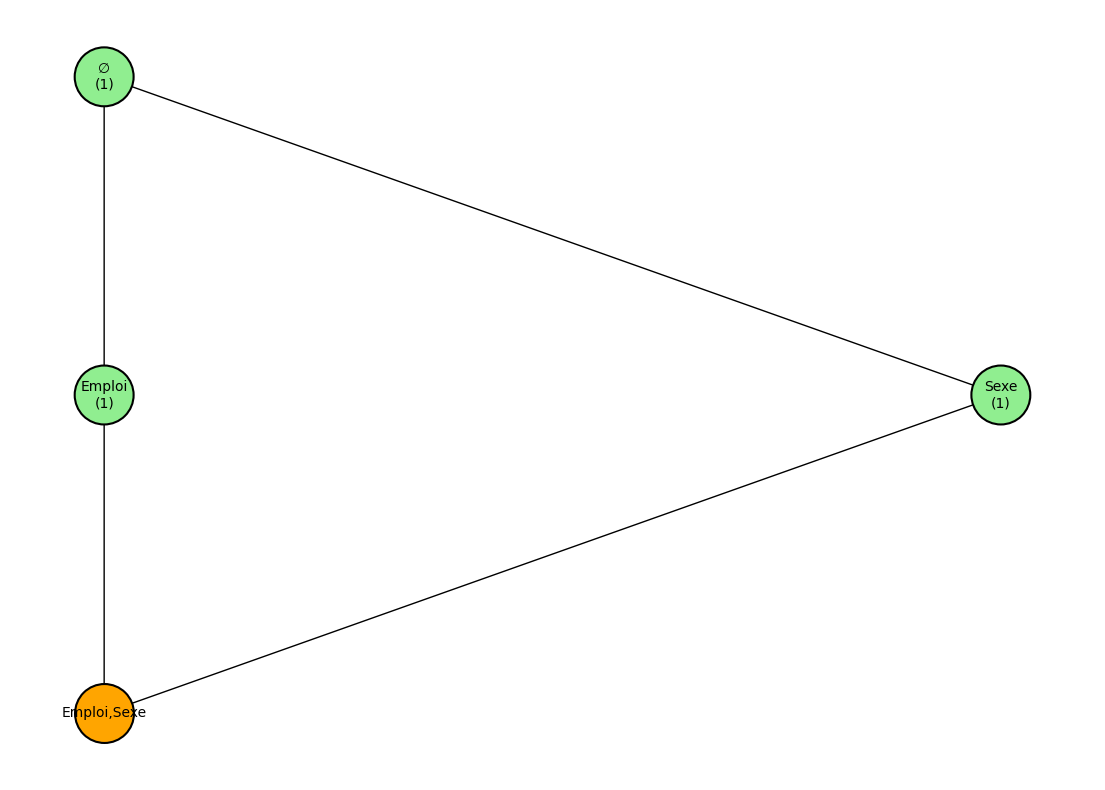

In [314]:
from itertools import combinations

def powerset_frozensets(iterable):
    return [frozenset(s) for r in range(len(iterable)+1) for s in combinations(iterable, r)]

variables = ['Sexe', 'Emploi']
liste_request = powerset_frozensets(variables)

plot_subset_tree(liste_request)

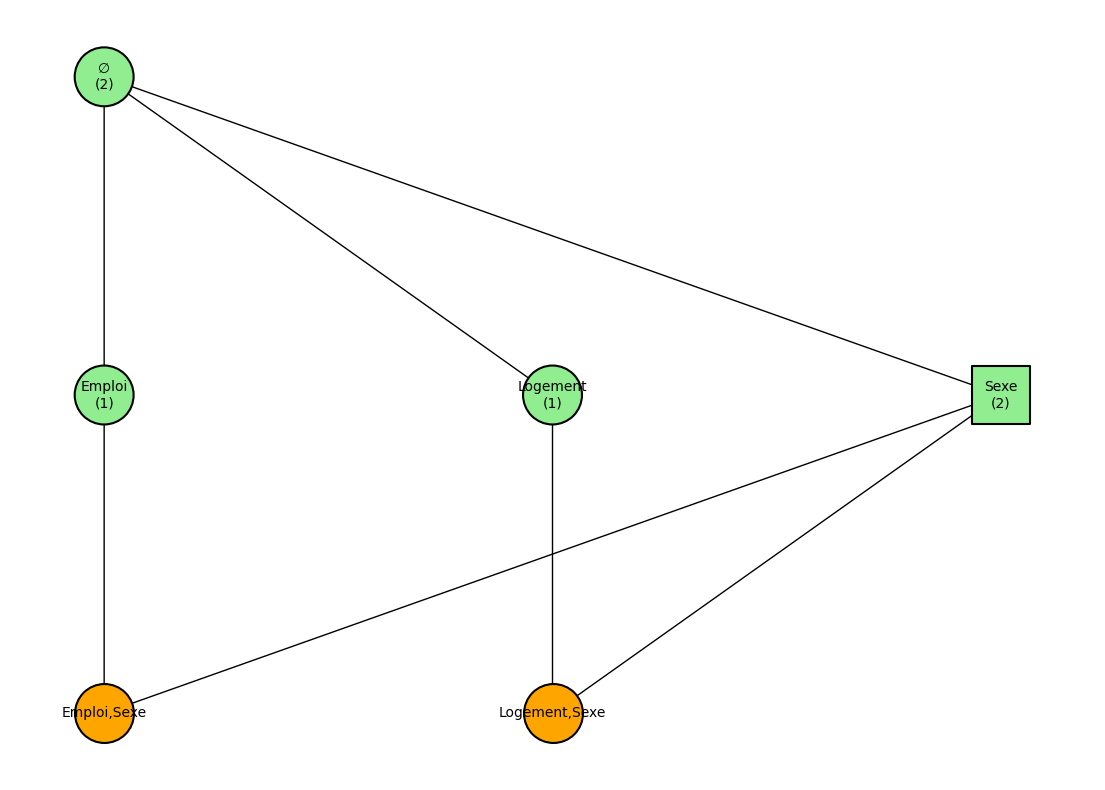

In [315]:
from itertools import combinations

def powerset_frozensets(iterable):
    return [frozenset(s) for r in range(len(iterable)+1) for s in combinations(iterable, r)]

variables = ['Sexe', 'Emploi', 'Logement']
liste_request = powerset_frozensets(variables)
liste_request = [fs for fs in liste_request if fs != frozenset({'Sexe', 'Emploi', 'Logement'}) and fs != frozenset({ 'Emploi', 'Logement'})]

plot_subset_tree(liste_request)

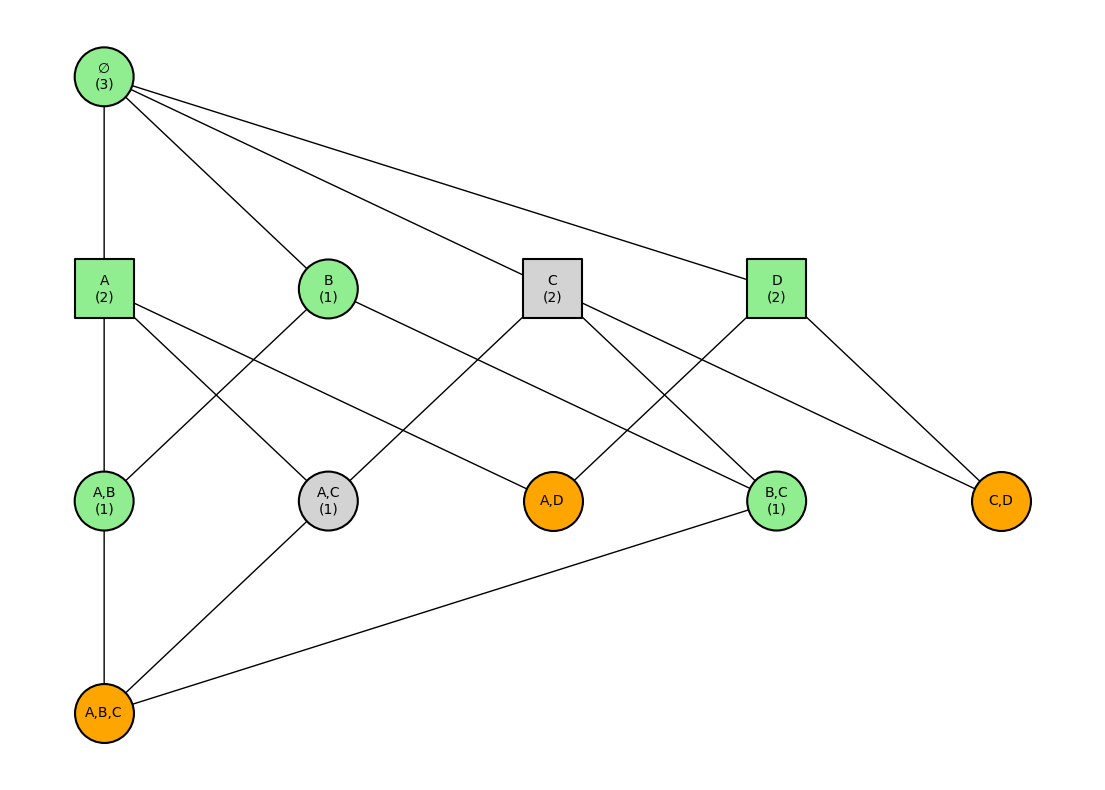

In [316]:
from itertools import combinations

def powerset_frozensets(iterable):
    return [frozenset(s) for r in range(len(iterable)+1) for s in combinations(iterable, r)]

variables = ['A', 'B', 'C']
liste_request = powerset_frozensets(variables)
liste_request.extend([
    frozenset(['A', 'D']),
    frozenset(['C', 'D']),
    frozenset(['D']),
])
liste_request = [fs for fs in liste_request if fs != frozenset({'C'}) and fs != frozenset({'A', 'C'})]

plot_subset_tree(liste_request)

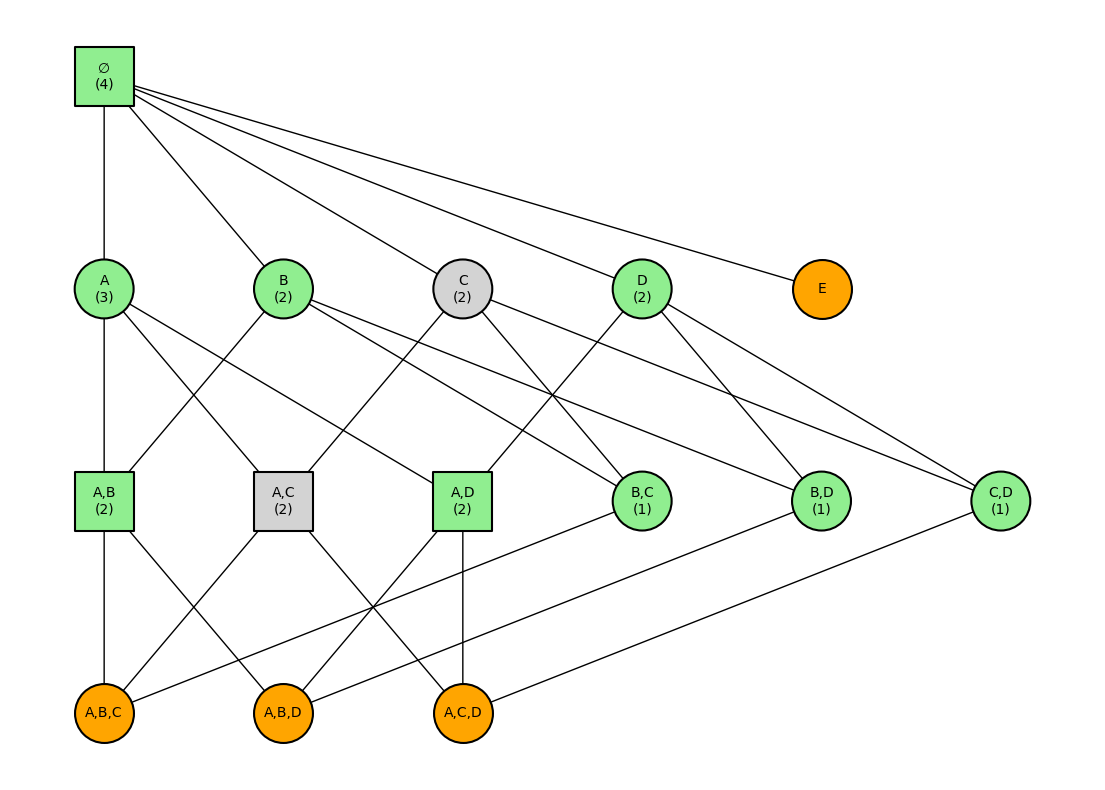

In [317]:
from itertools import combinations

# Exemple d'entrée
variables = ['A', 'B', 'C', 'D']
def powerset_frozensets(iterable):
    return [frozenset(s) for r in range(len(iterable)+1) for s in combinations(iterable, r)]

liste_request = powerset_frozensets(variables)
liste_request.extend([
    frozenset(['A', 'D']),
    frozenset(['C', 'D']),
    frozenset(['D']),
    frozenset(['E']),
])
liste_request = [fs for fs in liste_request if fs not in [
    frozenset({'C'}),
    frozenset({'A', 'C'}),
    frozenset({'A', 'B', 'C', 'D'}),
    frozenset({'B', 'C', 'D'})
]]

# Appel de la fonction
plot_subset_tree(liste_request)

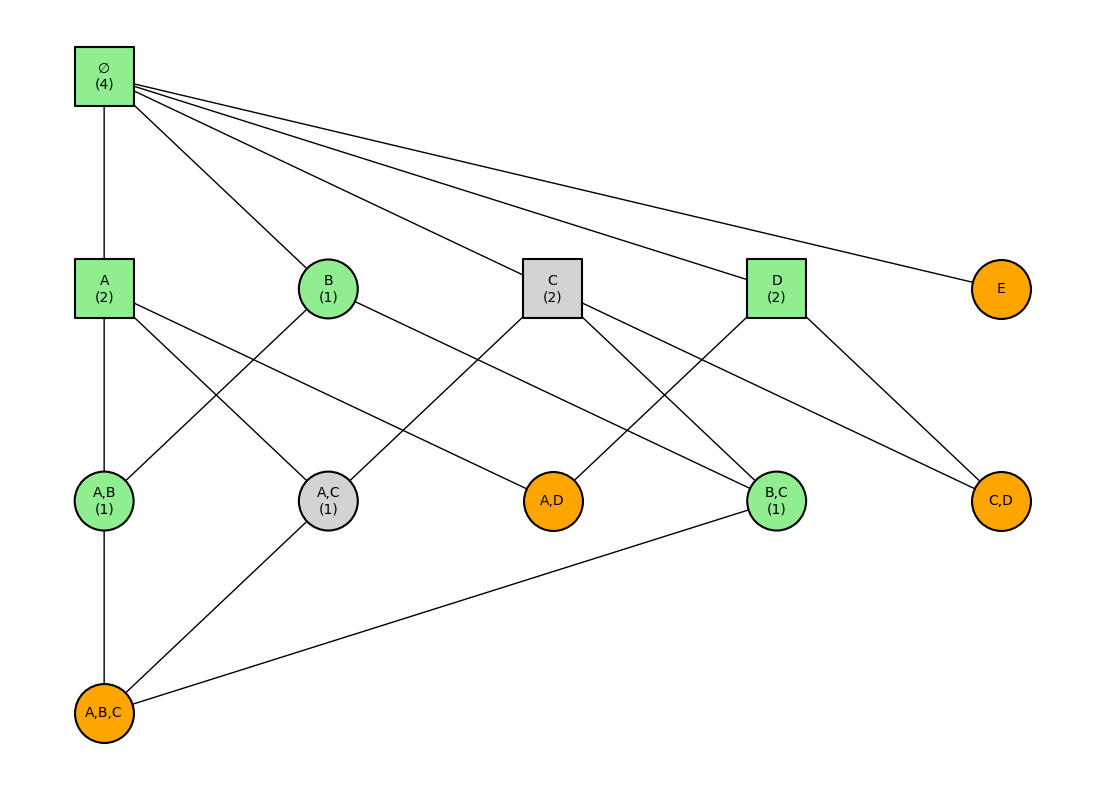

In [318]:
from itertools import combinations

variables = ['A', 'B', 'C']
dict_nb_modalite_variables = {var: 2 for var in variables}

def powerset_frozensets(iterable):
    return [frozenset(s) for r in range(len(iterable)+1) for s in combinations(iterable, r)]

liste_request = powerset_frozensets(variables)
liste_request.extend([
    frozenset(['A', 'D']),
    frozenset(['C', 'D']),
    frozenset(['D']),
    frozenset(['E']),
])

liste_request = [fs for fs in liste_request if fs not in [
    frozenset({'C'}),
    frozenset({'A', 'C'}),
    frozenset({'A', 'B', 'C', 'D'}),
    frozenset({'B', 'C', 'D'})
]]

# Appel de la fonction
plot_subset_tree(liste_request)


# Fin graph

In [19]:
from functools import reduce
import operator
import pandas as pd
import numpy as np
from itertools import combinations, product
from collections import defaultdict

# 1. Définition des variables
variables = ['A', 'B', 'C']
dict_nb_modalite_variables = {var: 2 for var in variables}

def powerset_frozensets(iterable):
    return [frozenset(s) for r in range(len(iterable)+1) for s in combinations(iterable, r)]

liste_request = powerset_frozensets(variables)
liste_request.extend([
    frozenset(['A', 'D']),
    frozenset(['C', 'D']),
    frozenset(['D']),
    frozenset(['E']),
])
liste_request = [fs for fs in liste_request if fs not in [
    frozenset({'C'}),
    frozenset({'A', 'C'}),
    frozenset({'A', 'B', 'C', 'D'}),
    frozenset({'B', 'C', 'D'})
]]

dict_nb_modalite_variables['D'] = 2
dict_nb_modalite_variables['E'] = 2

# Trouver les maximaux (non inclus dans d'autres strictement plus grands)
maximaux = [
    req for req in liste_request
    if not any((req < other) for other in liste_request)
]

non_maximaux = [req for req in liste_request if req not in maximaux]
liste_request = (
    sorted(maximaux, key=lambda x: -len(x)) +
    sorted(non_maximaux, key=lambda x: -len(x))
)

# Calcul de p
def produit_modalites(fset):
    if not fset:
        return 1
    return reduce(operator.mul, (dict_nb_modalite_variables[v] for v in fset), 1)

p = sum(produit_modalites(fset) for fset in maximaux)
n = sum(produit_modalites(fset) for fset in liste_request)

# Affichage
print("Tous les frozensets :", liste_request)
print("Requêtes maximales :", maximaux)
print("Nombre de colonnes de X: p =", p)
print("Nombre de lignes de X: n =", n)


# 6. Génération des noms des bêtas
beta_names = [f"beta_{i+1}" for i in range(p)]

# 7. Construction des DataFrames pour chaque requête maximale
df_par_requete = {}
compteur = 0

for req in maximaux:
    sorted_vars = sorted(req)
    domains = [range(dict_nb_modalite_variables[v]) for v in sorted_vars]
    combinations_vals = list(product(*domains))  # toutes les combinaisons pour cette requête
    nb = len(combinations_vals)

    # Associer les bonnes bêtas
    betas = beta_names[compteur:compteur + nb]
    compteur += nb

    # Construire le DataFrame
    df = pd.DataFrame(combinations_vals, columns=sorted_vars)
    df["value"] = betas
    df_par_requete[req] = df

# --- Affichage de contrôle ---
print("beta_names =", beta_names)
print("\nExemple pour la requête maximale :", list(df_par_requete.keys())[0])
print(df_par_requete[list(df_par_requete.keys())[0]])

# 8. Construction de la matrice X (n x p)
X = np.zeros((n, p), dtype=int)

# 8.1 Première partie : identité pour les lignes correspondant aux β
for i in range(p):
    X[i, i] = 1

# 8.2 Reste : combinaisons/group_by
ligne_courante = p  # on commence après les p premières lignes
for req in liste_request:
    if req in maximaux:
        continue  # déjà traité via identité

    # Chercher un maximal qui contient la requête
    for max_req in maximaux:
        if req <= max_req:
            df = df_par_requete[max_req].copy()
            # groupby + concaténation des strings de valeurs
            if len(req) > 0:
                grouped = df.groupby(sorted(req))["value"].apply(lambda x: ' + '.join(x)).reset_index()
            else:
                # cas du total : groupby sur rien → tout sommer
                grouped = pd.DataFrame({'value': [' + '.join(df["value"])]})

            for _, row in grouped.iterrows():
                beta_sum = row["value"]
                for b in beta_sum.split(" + "):
                    j = beta_names.index(b)
                    X[ligne_courante, j] = 1
                ligne_courante += 1
            break

# 9. Vérification
print(f"Matrice X : shape = {X.shape}")
print(X)

# 10. R
R_rows = []

# On parcourt toutes les paires de requêtes maximales
for req1, req2 in combinations(maximaux, 2):
    intersection = req1 & req2
    df1 = df_par_requete[req1]
    df2 = df_par_requete[req2]

    if not intersection:
        # Cas particulier : contrainte sur le total global (somme de toutes les cellules)
        betas1 = df1["value"].tolist()
        betas2 = df2["value"].tolist()

        row = np.zeros(len(beta_names))
        for b in betas1:
            row[beta_names.index(b)] = 1
        for b in betas2:
            row[beta_names.index(b)] -= 1
        R_rows.append(row)
        continue

    # Regrouper par les variables communes (intersection)
    grouped1 = df1.groupby(list(intersection))["value"].apply(list)
    grouped2 = df2.groupby(list(intersection))["value"].apply(list)

    # On parcourt les modalités communes aux deux tables
    common_modalities = grouped1.index.intersection(grouped2.index)

    modalities = list(common_modalities)

    for modality in modalities:
        betas1 = grouped1[modality]
        betas2 = grouped2[modality]

        row = np.zeros(len(beta_names))
        for b in betas1:
            row[beta_names.index(b)] =  1
        for b in betas2:
            row[beta_names.index(b)] -= 1
        R_rows.append(row)

def remove_dependent_rows_qr(R, tol=1e-10):
    if R.shape[0] == 0:
        return R
    Q, R_qr = np.linalg.qr(R.T)  # QR sur les colonnes revient à détecter les lignes dépendantes
    independent = np.abs(R_qr).sum(axis=1) > tol
    return R[independent]

# Finalisation
R = np.vstack(R_rows) if R_rows else np.empty((0, len(beta_names)))
R = remove_dependent_rows_qr(R)
print("R.shape =", R.shape)
print("R (matrice des contraintes):")
print(R)

Tous les frozensets : [frozenset({'A', 'B', 'C'}), frozenset({'A', 'D'}), frozenset({'D', 'C'}), frozenset({'E'}), frozenset({'A', 'B'}), frozenset({'B', 'C'}), frozenset({'A'}), frozenset({'B'}), frozenset({'D'}), frozenset()]
Requêtes maximales : [frozenset({'A', 'B', 'C'}), frozenset({'A', 'D'}), frozenset({'D', 'C'}), frozenset({'E'})]
Nombre de colonnes de X: p = 18
Nombre de lignes de X: n = 33
beta_names = ['beta_1', 'beta_2', 'beta_3', 'beta_4', 'beta_5', 'beta_6', 'beta_7', 'beta_8', 'beta_9', 'beta_10', 'beta_11', 'beta_12', 'beta_13', 'beta_14', 'beta_15', 'beta_16', 'beta_17', 'beta_18']

Exemple pour la requête maximale : frozenset({'A', 'B', 'C'})
   A  B  C   value
0  0  0  0  beta_1
1  0  0  1  beta_2
2  0  1  0  beta_3
3  0  1  1  beta_4
4  1  0  0  beta_5
5  1  0  1  beta_6
6  1  1  0  beta_7
7  1  1  1  beta_8
Matrice X : shape = (33, 18)
[[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0

In [20]:
import numpy as np
import itertools
# Hypothèse : X et R sont déjà définies
# Dimensions
n, p = X.shape

dict_request ={fset: {"nb_cellule":produit_modalites(fset), "sigma2":25} for fset in liste_request}
# Matrice de variance Omega (hétéroscédastique)
sigma2 = np.array(list(itertools.chain.from_iterable(
    [v["sigma2"]] * v["nb_cellule"] for v in dict_request.values()
)))

rho_cout = sum(1/sigma2)/2
Omega_inv = np.diag(1 / sigma2)

# Matrice H = X^T Omega^{-1} X
H = X.T @ Omega_inv @ X
H_inv = np.linalg.inv(H)

# Projection liée à la contrainte R beta = 0
RHinv = R @ H_inv
middle_term = np.linalg.inv(RHinv @ R.T)
correction = H_inv @ R.T @ middle_term @ RHinv

# Variance corrigée de beta_hat sous contrainte R beta = 0
V_beta_constrained = H_inv - correction

# Facultatif : Variance de X beta (si tu veux l'effet de la contrainte sur les sorties)
V_Xbeta_constrained = X @ V_beta_constrained @ X.T
var_Xbeta_constrained = np.diag(V_Xbeta_constrained)

# Affichage
print("Variances de Xβ corrigées :", var_Xbeta_constrained)
rho_obtenue = sum(1/var_Xbeta_constrained)/2
print("Rho couté :", rho_cout)
print("Précicsion en rho obtenue :", rho_obtenue)


Variances de Xβ corrigées : [ 9.74747475  9.74747475  9.74747475  9.74747475  9.74747475  9.74747475
  9.74747475  9.74747475  9.58017677  9.58017677  9.58017677  9.58017677
 10.69128788 10.69128788 10.69128788 10.69128788 14.01515152 14.01515152
  7.32323232  7.32323232  7.32323232  7.32323232  8.43434343  8.43434343
  8.43434343  8.43434343  7.07070707  7.07070707  7.07070707  7.07070707
  7.76515152  7.76515152  6.06060606]
Rho couté : 0.6600000000000003
Précicsion en rho obtenue : 1.8819134901978813


In [23]:
import numpy as np
import cvxpy as cp

# Dimensions
n, p = X.shape

# Données fictives
sigma2 = 25 * np.ones(n) # variances hétéroscédastiques
Omega = np.diag(sigma2)
Omega_inv = np.diag(1 / sigma2)

# Matrice de variance-covariance de beta_hat
Xt_Omega_inv = X.T @ Omega_inv
#V_beta = np.linalg.inv(Xt_Omega_inv @ X)
V_beta = np.linalg.pinv(X.T @ Omega_inv @ X)

# Matrice de variance de X @ beta
V_Xbeta = X @ V_beta @ X.T

# Extraire uniquement les variances (diagonale)
var_Xbeta = np.diag(V_Xbeta)

print("Variances de Xβ :", var_Xbeta)

Variances de Xβ : [ 6.06060606  7.07070707  7.07070707  7.07070707  7.07070707  7.32323232
  7.32323232  7.32323232  7.32323232  8.43434343  8.43434343  8.43434343
  8.43434343  9.74747475  9.74747475  9.74747475  9.74747475  9.74747475
  9.74747475  9.74747475  9.74747475  9.58017677  9.58017677  9.58017677
  9.58017677 10.69128788 10.69128788 10.69128788 10.69128788  7.76515152
  7.76515152 14.01515152 14.01515152]


# Construction


In [25]:
from functools import reduce
import operator
import pandas as pd
import numpy as np
from itertools import product

# 1. Définition des variables et de leurs modalités
dict_nb_modalite_variables = {
    'A': 2,
    'B': 2,
    'C': 2,
    'D': 2,
    'E': 2
}

variables = list(dict_nb_modalite_variables.keys())

liste_request = powerset_frozensets(['A', 'B', 'C'])
liste_request.extend([
    frozenset(['A', 'D']),
    frozenset(['C', 'D']),
    frozenset(['D']),
    frozenset(['E']),
])
liste_request = [fs for fs in liste_request if fs not in [
    frozenset({'C'}),
    frozenset({'A', 'C'}),
    frozenset({'A', 'B', 'C', 'D'}),
    frozenset({'B', 'C', 'D'})
]]


# 2. Calcul de p = produit des modalités de toutes les variables
def produit_modalites(vars):
    return reduce(operator.mul, (dict_nb_modalite_variables[v] for v in vars), 1)

p = produit_modalites(variables)
n = sum(produit_modalites(fset) for fset in liste_request)

# 3. Génération de toutes les combinaisons de modalités
domains = [range(dict_nb_modalite_variables[v]) for v in variables]
combinations_vals = list(product(*domains))  # produit cartésien

# 4. Génération des noms des beta
beta_names = [f"beta_{i+1}" for i in range(p)]

# 5. Construction du DataFrame final
df = pd.DataFrame(combinations_vals, columns=variables)
df["value"] = beta_names

# 6. Affichage (facultatif)
print(f"Nombre de colonnes (variables) : {len(variables)}")
print(f"Nombre de lignes (p) : {p}")
print(df.head())
print(liste_request)

# 8. Construction de la matrice X (n x p)
X = np.zeros((n, p), dtype=int)
i = 0
for req in liste_request:
    df_copy = df.copy()
    # groupby + concaténation des strings de valeurs
    if len(req) > 0:
        grouped = df_copy.groupby(sorted(req))["value"].apply(lambda x: ' + '.join(x)).reset_index()
    else:
        # cas du total : groupby sur rien → tout sommer
        grouped = pd.DataFrame({'value': [' + '.join(df["value"])]})

    for _, row in grouped.iterrows():
        beta_sum = row["value"]
        for b in beta_sum.split(" + "):
            j = beta_names.index(b)
            X[i, j] = 1
        i += 1

# 9. Vérification
print(f"Matrice X : shape = {X.shape}")
print(X)

Nombre de colonnes (variables) : 5
Nombre de lignes (p) : 32
   A  B  C  D  E   value
0  0  0  0  0  0  beta_1
1  0  0  0  0  1  beta_2
2  0  0  0  1  0  beta_3
3  0  0  0  1  1  beta_4
4  0  0  1  0  0  beta_5
[frozenset(), frozenset({'A'}), frozenset({'B'}), frozenset({'A', 'B'}), frozenset({'B', 'C'}), frozenset({'A', 'B', 'C'}), frozenset({'A', 'D'}), frozenset({'D', 'C'}), frozenset({'D'}), frozenset({'E'})]
Matrice X : shape = (33, 32)
[[1 1 1 ... 1 1 1]
 [1 1 1 ... 0 0 0]
 [0 0 0 ... 1 1 1]
 ...
 [0 0 1 ... 0 1 1]
 [1 0 1 ... 0 1 0]
 [0 1 0 ... 1 0 1]]


In [27]:
print("Rang de X :", np.linalg.matrix_rank(X))
print("Rang de Xt_Omega_inv @ X :", np.linalg.matrix_rank(Xt_Omega_inv @ X))

eigvals = np.linalg.eigvalsh(Xt_Omega_inv @ X)
print("Valeurs propres de Xt_Omega_inv @ X :", eigvals)

Rang de X : 12
Rang de Xt_Omega_inv @ X : 12
Valeurs propres de Xt_Omega_inv @ X : [-4.66111495e-16 -2.63732674e-16 -2.19472720e-16 -1.83618439e-16
 -1.37532981e-16 -1.26283331e-16 -1.14533624e-16 -9.45826287e-17
 -4.71817135e-17 -1.57641090e-17 -6.18970489e-18  3.39785386e-17
  4.57323735e-17  6.07460610e-17  7.93587040e-17  8.68732650e-17
  1.32760294e-16  1.45541813e-16  3.09234306e-16  7.39530986e-16
  1.60000000e-01  1.60000000e-01  3.20000000e-01  3.20000000e-01
  4.80000000e-01  4.80000000e-01  6.40000000e-01  8.00000000e-01
  1.28000000e+00  1.44000000e+00  1.44000000e+00  5.28000000e+00]


In [52]:
# Y synthétique, variance hétéroscédastique
np.random.seed(123)
Y = np.random.poisson(lam=25, size=n)
sigma2 = np.linspace(5, 20, n)
Omega_inv = np.diag(1 / sigma2)

# Optimisation
beta = cp.Variable(p)
objective = cp.Minimize(cp.quad_form(Y - X @ beta, Omega_inv))
constraints = [beta >= 0]
problem = cp.Problem(objective, constraints)
problem.solve()

# Résultat
X_beta = X @ beta.value
X_beta_rounded = np.round(X_beta).astype(int)
print("X @ beta estimé :", X_beta_rounded)

X @ beta estimé : [53 25 28 27 25 13 12 14 13 12 15 14 11  9  3  6  6  2 12  9  5 16  9 10
 18 11 15 14 12 26 27 31 22]
